# Scenario 4 – Potential Energy Waste Detection

## Objective

Detect time intervals with potential lighting-related energy waste in Room 4.9 by combining desk occupancy, PIR activity, indoor light level and time-of-day information.

The analysis distinguishes high-confidence nighttime cases from lower-confidence daytime cases, where natural daylight may influence the light sensor measurements.

In [1]:
# IMPORTS AND SETTINGS

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 160)

plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.grid"] = True
plt.rcParams["font.size"] = 11

print("Imports completed successfully.")

Imports completed successfully.


In [2]:
# LOAD DATASETS

room_23 = pd.read_csv("room_2_3_final.csv")
room_39 = pd.read_csv("room_3_9_final.csv")
room_49 = pd.read_csv("room_4_9_full_dataset.csv")

datasets = {
    "Room 2.3": room_23,
    "Room 3.9": room_39,
    "Room 4.9": room_49
}

for name, data in datasets.items():

    data["ts"] = pd.to_datetime(
        data["ts"],
        errors="coerce"
    )

    data.dropna(
        subset=["ts"],
        inplace=True
    )

    data.sort_values(
        "ts",
        inplace=True
    )

    data.reset_index(
        drop=True,
        inplace=True
    )

    print("=" * 70)
    print(name)
    print("=" * 70)
    print("Rows:", data.shape[0])
    print("Columns:", data.shape[1])
    print("Time range:", data["ts"].min(), "→", data["ts"].max())
    print()

# The energy-waste analysis will be performed on Room 4.9.
df = room_49.copy()

print("Room 4.9 selected for the energy-waste analysis.")
display(df.head())

Room 2.3
Rows: 38645
Columns: 10
Time range: 2025-09-01 14:40:00 → 2026-05-27 23:20:00

Room 3.9
Rows: 38307
Columns: 12
Time range: 2025-08-31 23:40:00 → 2026-05-28 16:50:00

Room 4.9
Rows: 38692
Columns: 59
Time range: 2025-09-01 20:40:00 → 2026-06-05 06:50:00

Room 4.9 selected for the energy-waste analysis.


,ts,co2_iaq1,temperature_iaq1,humidity_iaq1,light_level_iaq1,pir_iaq1,co2_iaq2,temperature_iaq2,humidity_iaq2,light_level_iaq2,pir_iaq2,co2_avg,temperature_avg,humidity_avg,light_level_avg,pir_any,available_iaq_sensors,desk_1,desk_2,desk_3,desk_4,desk_5,desk_6,desk_7,desk_8,desk_9,desk_10,desk_11,desk_12,desk_13,desk_14,desk_15,desk_16,desk_17,desk_18,desk_19,desk_20,desk_21,desk_22,desk_23,desk_24,desk_25,desk_26,desk_27,desk_28,desk_29,desk_30,desk_31,desk_32,occupied_desks,free_desks,occupancy_rate,any_desk_occupied,mc_1,mc_2,mc_3,mc_4,open_windows,open_windows_binary
0,2025-09-01 20:40:00,583.0,29.3,42.5,0.0,0.0,577.0,29.2,42.5,0.0,0.0,580.0,29.25,42.50,0.0,0,2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,32,0.0,0,1,0,0,0,1,1
1,2025-09-01 20:50:00,580.0,29.3,42.5,0.0,0.0,575.0,29.2,42.5,0.0,0.0,577.5,29.25,42.50,0.0,0,2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,32,0.0,0,1,0,0,0,1,1
2,2025-09-01 21:00:00,577.0,29.3,42.5,0.0,0.0,571.0,29.2,42.5,0.0,0.0,574.0,29.25,42.50,0.0,0,2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,32,0.0,0,1,0,0,0,1,1
3,2025-09-01 21:10:00,572.0,29.3,42.5,0.0,0.0,566.0,29.2,43.0,0.0,0.0,569.0,29.25,42.75,0.0,0,2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,32,0.0,0,1,0,0,0,1,1
4,2025-09-01 21:20:00,568.0,29.3,42.5,0.0,0.0,561.0,29.2,43.0,0.0,0.0,564.5,29.25,42.75,0.0,0,2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,32,0.0,0,1,0,0,0,1,1


## 1. Data Availability and Room Selection

The analysis first compares the availability of the variables required for potential energy-waste detection across the three monitored rooms.

Room 4.9 is selected for the subsequent analysis because it provides the required desk occupancy, PIR activity and indoor light-level measurements.

In [3]:
# DATA AVAILABILITY AND QUALITY CHECK

# Variables relevant to Scenario 4
scenario4_variables = [
    "ts",
    "occupied_desks",
    "any_desk_occupied",
    "pir_any",
    "light_level_avg"
]

# --------------------------------------------------
# 1. COMPARE VARIABLE AVAILABILITY ACROSS ROOMS
# --------------------------------------------------

availability_rows = []

for room_name, data in datasets.items():

    row = {
        "Room": room_name,
        "Rows": len(data)
    }

    for column in scenario4_variables:
        row[column] = (
            "Available"
            if column in data.columns
            else "Not available"
        )

    availability_rows.append(row)

availability_summary = pd.DataFrame(
    availability_rows
)

print(
    "Scenario 4 variable availability "
    "across rooms:\n"
)

display(availability_summary)

# --------------------------------------------------
# 2. SELECT ROOM 4.9 FOR ENERGY-WASTE ANALYSIS
# --------------------------------------------------

required_columns = [
    "ts",
    "occupied_desks",
    "any_desk_occupied",
    "pir_any",
    "light_level_avg"
]

missing_columns = [
    column
    for column in required_columns
    if column not in df.columns
]

if missing_columns:
    raise ValueError(
        f"Missing required columns in Room 4.9: "
        f"{missing_columns}"
    )

print(
    "\nAll required Scenario 4 variables "
    "are available in Room 4.9."
)

# --------------------------------------------------
# 3. CHECK MISSING VALUES
# --------------------------------------------------

missing_summary = (
    df[required_columns]
    .isna()
    .sum()
    .reset_index()
)

missing_summary.columns = [
    "Variable",
    "Missing values"
]

display(missing_summary)

# --------------------------------------------------
# 4. KEY VARIABLE DISTRIBUTIONS
# --------------------------------------------------

print("\nOccupied desks distribution:")
display(
    df["occupied_desks"]
    .value_counts(dropna=False)
    .sort_index()
    .to_frame("Observations")
)

print("\nPIR distribution:")
display(
    df["pir_any"]
    .value_counts(dropna=False)
    .sort_index()
    .to_frame("Observations")
)

print("\nLight level summary:")
display(
    df["light_level_avg"]
    .describe()
    .round(2)
)

Scenario 4 variable availability across rooms:



,Room,Rows,ts,occupied_desks,any_desk_occupied,pir_any,light_level_avg
0,Room 2.3,38645,Available,Not available,Not available,Not available,Not available
1,Room 3.9,38307,Available,Not available,Not available,Not available,Not available
2,Room 4.9,38692,Available,Available,Available,Available,Available



All required Scenario 4 variables are available in Room 4.9.


,Variable,Missing values
0,ts,0
1,occupied_desks,0
2,any_desk_occupied,0
3,pir_any,0
4,light_level_avg,0



Occupied desks distribution:


,Observations
occupied_desks,
0,32388
1,2043
2,551
3,324
4,283
5,254
6,260
7,202
8,207



PIR distribution:


,Observations
pir_any,
0,35431
1,3261



Light level summary:


,light_level_avg
count,38692.00
mean,0.38
std,0.74
min,0.00
25%,0.00
50%,0.00
75%,0.50
max,3.00


## 2. Feature Engineering

Time-of-day, occupancy and lighting indicators are derived from the available sensor measurements.

The room is considered occupied when at least one desk is active. Daytime is operationally defined as 08:00–18:59, while all remaining hours are treated as nighttime.

In [4]:
# FEATURE ENGINEERING

df["hour"] = df["ts"].dt.hour
df["day_of_week"] = df["ts"].dt.dayofweek

df["is_weekend"] = (
    df["day_of_week"] >= 5
).astype(int)

# Operational daytime window.
# Daytime lighting cases are treated more cautiously because
# natural daylight may affect the light sensor measurements.
df["is_daytime"] = (
    df["hour"].between(8, 18)
).astype(int)

df["is_nighttime"] = (
    df["is_daytime"] == 0
).astype(int)

# Room occupancy state based on the existing
# binary Desk Occupancy indicator.
df["room_occupied"] = (
    df["any_desk_occupied"]
).astype(int)

df["room_empty"] = (
    1 - df["room_occupied"]
)

# Auxiliary binary indicator used only for
# descriptive exploration of light measurements.
# Any positive value indicates that some light
# level was detected by the sensor.
df["lighting_detected"] = (
    df["light_level_avg"] > 0
).astype(int)

print(
    "Feature engineering completed successfully."
)

display(
    df[
        [
            "ts",
            "hour",
            "day_of_week",
            "is_weekend",
            "room_occupied",
            "room_empty",
            "pir_any",
            "light_level_avg",
            "lighting_detected",
            "is_daytime",
            "is_nighttime"
        ]
    ].head(10)
)

Feature engineering completed successfully.


,ts,hour,day_of_week,is_weekend,room_occupied,room_empty,pir_any,light_level_avg,lighting_detected,is_daytime,is_nighttime
0,2025-09-01 20:40:00,20,0,0,0,1,0,0.0,0,0,1
1,2025-09-01 20:50:00,20,0,0,0,1,0,0.0,0,0,1
2,2025-09-01 21:00:00,21,0,0,0,1,0,0.0,0,0,1
3,2025-09-01 21:10:00,21,0,0,0,1,0,0.0,0,0,1
4,2025-09-01 21:20:00,21,0,0,0,1,0,0.0,0,0,1
5,2025-09-01 21:30:00,21,0,0,0,1,0,0.0,0,0,1
6,2025-09-01 21:40:00,21,0,0,0,1,0,0.0,0,0,1
7,2025-09-01 21:50:00,21,0,0,0,1,0,0.0,0,0,1
8,2025-09-01 22:00:00,22,0,0,0,1,0,0.0,0,0,1
9,2025-09-01 22:10:00,22,0,0,0,1,0,0.0,0,0,1


LIGHT LEVEL STATISTICS


,light_level_avg
count,38692.00
mean,0.38
std,0.74
min,0.00
25%,0.00
50%,0.00
75%,0.50
max,3.00



Observations with detected light: 9853
Empty-room observations with detected light: 4980
Percentage of all observations with detected light: 25.47 %
Percentage of all observations with empty room and detected light: 12.87 %


,Light level
0.50,0.0
0.75,0.5
0.90,2.0
0.95,2.0
0.99,3.0


,Threshold,Observations,Percentage (%)
0,Light level >= 1,8083,20.89
1,Light level >= 2,5176,13.38


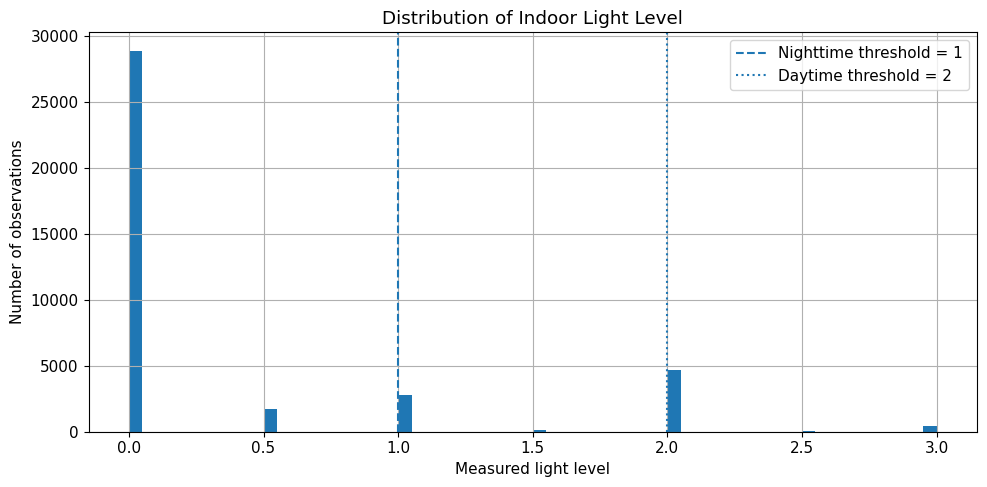

In [5]:
# LIGHTING ANALYSIS

print("=" * 70)
print("LIGHT LEVEL STATISTICS")
print("=" * 70)

# --------------------------------------------------
# 1. BASIC DESCRIPTIVE STATISTICS
# --------------------------------------------------

light_stats = (
    df["light_level_avg"]
    .describe()
    .round(2)
)

display(light_stats)

# --------------------------------------------------
# 2. LIGHTING DETECTION COUNTS
# --------------------------------------------------

lighting_detected_count = (
    df["lighting_detected"] == 1
).sum()

empty_lighting_count = (
    (df["room_empty"] == 1)
    &
    (df["lighting_detected"] == 1)
).sum()

print(
    "\nObservations with detected light:",
    lighting_detected_count
)

print(
    "Empty-room observations with detected light:",
    empty_lighting_count
)

print(
    "Percentage of all observations with detected light:",
    round(
        100 * lighting_detected_count / len(df),
        2
    ),
    "%"
)

print(
    "Percentage of all observations with "
    "empty room and detected light:",
    round(
        100 * empty_lighting_count / len(df),
        2
    ),
    "%"
)

# --------------------------------------------------
# 3. LIGHT LEVEL PERCENTILES
# --------------------------------------------------

light_percentiles = (
    df["light_level_avg"]
    .quantile(
        [
            0.50,
            0.75,
            0.90,
            0.95,
            0.99
        ]
    )
    .round(2)
    .to_frame("Light level")
)

display(light_percentiles)

# --------------------------------------------------
# 4. OBSERVATIONS ABOVE CANDIDATE THRESHOLDS
# --------------------------------------------------

threshold_summary = pd.DataFrame({
    "Threshold": [
        "Light level >= 1",
        "Light level >= 2"
    ],
    "Observations": [
        (df["light_level_avg"] >= 1).sum(),
        (df["light_level_avg"] >= 2).sum()
    ]
})

threshold_summary["Percentage (%)"] = (
    threshold_summary["Observations"]
    / len(df)
    * 100
).round(2)

display(threshold_summary)

# --------------------------------------------------
# 5. LIGHT LEVEL DISTRIBUTION
# --------------------------------------------------

plt.figure(figsize=(10, 5))

plt.hist(
    df["light_level_avg"],
    bins=60
)

plt.axvline(
    1,
    linestyle="--",
    label="Nighttime threshold = 1"
)

plt.axvline(
    2,
    linestyle=":",
    label="Daytime threshold = 2"
)

plt.xlabel("Measured light level")
plt.ylabel("Number of observations")

plt.title(
    "Distribution of Indoor Light Level"
)

plt.legend()

plt.tight_layout()

plt.savefig(
    "Figure_Energy_1_Light_Level_Distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 3. Rule-Based Potential Energy Waste Detection

Potential lighting-related energy waste is identified using an interpretable rule-based mechanism.

A room is considered confidently empty only when no desk occupancy and no PIR activity are detected simultaneously. Nighttime empty-room observations with a light level of at least 1 are classified as high-confidence potential waste.

During daytime, a higher light threshold of 2 is used because natural daylight may influence the sensor measurements. These cases are therefore classified as requiring further review rather than confirmed potential waste.

In [6]:
# ENERGY WASTE DETECTION ENGINE
# Rule-based identification of potential lighting-related energy waste

# --------------------------------------------------
# 1. CONFIRMED EMPTY ROOM
# --------------------------------------------------

# The room is considered confidently empty only when:
# - no desk is occupied
# - no PIR activity is detected
df["confirmed_empty"] = (
    (df["room_empty"] == 1)
    &
    (df["pir_any"] == 0)
)

# --------------------------------------------------
# 2. LIGHTING THRESHOLDS
# --------------------------------------------------

# Minimum meaningful light level used for
# nighttime potential-waste detection.
NIGHT_LIGHT_THRESHOLD = 1

# Higher threshold used during daytime because
# natural daylight may influence the sensor measurement.
DAY_LIGHT_THRESHOLD = 2

df["elevated_light"] = (
    df["light_level_avg"]
    >= NIGHT_LIGHT_THRESHOLD
)

df["high_daytime_light"] = (
    df["light_level_avg"]
    >= DAY_LIGHT_THRESHOLD
)

# --------------------------------------------------
# 3. INITIAL EVENT CATEGORY
# --------------------------------------------------

df["energy_event"] = (
    "No potential waste"
)

# --------------------------------------------------
# 4. HIGH-CONFIDENCE NIGHTTIME POTENTIAL WASTE
# --------------------------------------------------

night_waste_mask = (
    df["confirmed_empty"]
    &
    df["elevated_light"]
    &
    (df["is_nighttime"] == 1)
)

df.loc[
    night_waste_mask,
    "energy_event"
] = (
    "High-confidence nighttime potential waste"
)

# --------------------------------------------------
# 5. DAYTIME CASE REQUIRING REVIEW
# --------------------------------------------------

# Daytime cases are not classified as confirmed
# waste because natural daylight may contribute
# to the measured light level.
daytime_review_mask = (
    df["confirmed_empty"]
    &
    df["high_daytime_light"]
    &
    (df["is_daytime"] == 1)
)

df.loc[
    daytime_review_mask,
    "energy_event"
] = (
    "Daytime lighting case - review required"
)

# --------------------------------------------------
# 6. PIR ACTIVITY WITHOUT DESK OCCUPANCY
# --------------------------------------------------

# These observations are not treated as potential waste,
# because PIR activity may indicate temporary presence
# or movement through the room.
transitional_mask = (
    (df["room_empty"] == 1)
    &
    (df["pir_any"] == 1)
    &
    df["elevated_light"]
)

df.loc[
    transitional_mask,
    "energy_event"
] = (
    "PIR activity without desk occupancy"
)

# --------------------------------------------------
# 7. BINARY HIGH-CONFIDENCE INDICATOR
# --------------------------------------------------

df["potential_energy_waste"] = (
    df["energy_event"]
    == "High-confidence nighttime potential waste"
).astype(int)

print(
    "Energy Waste Detection completed successfully."
)

display(
    df[
        [
            "ts",
            "occupied_desks",
            "room_empty",
            "pir_any",
            "confirmed_empty",
            "light_level_avg",
            "is_daytime",
            "is_nighttime",
            "energy_event",
            "potential_energy_waste"
        ]
    ].head(20)
)

Energy Waste Detection completed successfully.


,ts,occupied_desks,room_empty,pir_any,confirmed_empty,light_level_avg,is_daytime,is_nighttime,energy_event,potential_energy_waste
0,2025-09-01 20:40:00,0,1,0,True,0.0,0,1,No potential waste,0
1,2025-09-01 20:50:00,0,1,0,True,0.0,0,1,No potential waste,0
2,2025-09-01 21:00:00,0,1,0,True,0.0,0,1,No potential waste,0
3,2025-09-01 21:10:00,0,1,0,True,0.0,0,1,No potential waste,0
4,2025-09-01 21:20:00,0,1,0,True,0.0,0,1,No potential waste,0
5,2025-09-01 21:30:00,0,1,0,True,0.0,0,1,No potential waste,0
6,2025-09-01 21:40:00,0,1,0,True,0.0,0,1,No potential waste,0
7,2025-09-01 21:50:00,0,1,0,True,0.0,0,1,No potential waste,0
8,2025-09-01 22:00:00,0,1,0,True,0.0,0,1,No potential waste,0
9,2025-09-01 22:10:00,0,1,0,True,0.0,0,1,No potential waste,0


## 4. Detected Event Categories

Each observation is assigned to one of four operational categories according to occupancy, PIR activity, light level and time of day.

The resulting distribution is used to quantify the frequency of high-confidence nighttime cases, daytime review cases and transitional PIR activity without desk occupancy.

In [7]:
# EVENT SUMMARY

event_summary = (
    df["energy_event"]
    .value_counts()
    .rename_axis("Event")
    .reset_index(name="Observations")
)

event_summary["Percentage (%)"] = (
    event_summary["Observations"]
    / len(df)
    * 100
).round(2)

display(event_summary)

high_confidence_count = int(
    df["potential_energy_waste"].sum()
)

high_confidence_percentage = (
    high_confidence_count
    / len(df)
    * 100
)

print(
    "\nHigh-confidence nighttime potential-waste observations:",
    high_confidence_count
)

print(
    "Percentage of all observations:",
    round(high_confidence_percentage, 2),
    "%"
)

event_summary.to_csv(
    "energy_waste_event_summary.csv",
    index=False
)

print(
    "\nSaved: energy_waste_event_summary.csv"
)

,Event,Observations,Percentage (%)
0,No potential waste,36489,94.31
1,High-confidence nighttime potential waste,1124,2.90
2,Daytime lighting case - review required,876,2.26
3,PIR activity without desk occupancy,203,0.52



High-confidence nighttime potential-waste observations: 1124
Percentage of all observations: 2.9 %

Saved: energy_waste_event_summary.csv


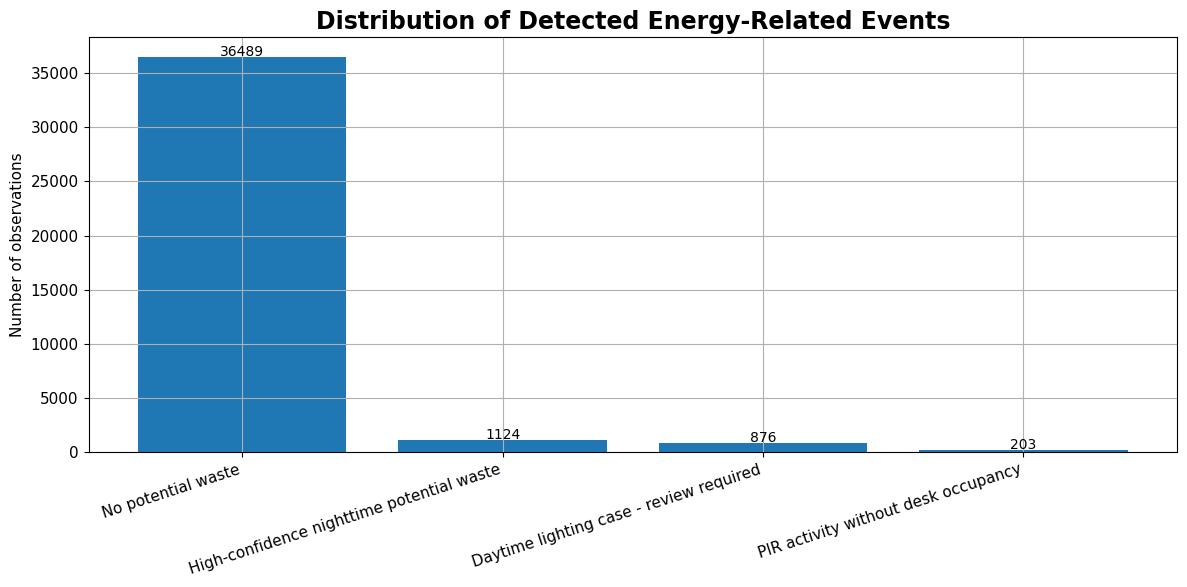

In [8]:
# EVENT DISTRIBUTION

plot_counts = (
    df["energy_event"]
    .value_counts()
)

plt.figure(figsize=(12,6))

bars = plt.bar(
    plot_counts.index,
    plot_counts.values
)

plt.title(
    "Distribution of Detected Energy-Related Events",
    fontsize=17,
    weight="bold"
)

plt.ylabel("Number of observations")
plt.xlabel("")

plt.xticks(
    rotation=18,
    ha="right"
)

# Add values above bars
for bar in bars:

    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 80,
        f"{int(height)}",
        ha="center",
        fontsize=10
    )

plt.tight_layout()

plt.savefig(
    "Figure_Energy_2_Event_Distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 5. Temporal Distribution of Potential Energy Waste

The temporal distribution of the detected events is examined to identify whether potential waste occurs randomly or is concentrated during specific periods.

The analysis includes the event timeline, the hourly distribution of high-confidence nighttime cases and a date-by-hour heatmap.

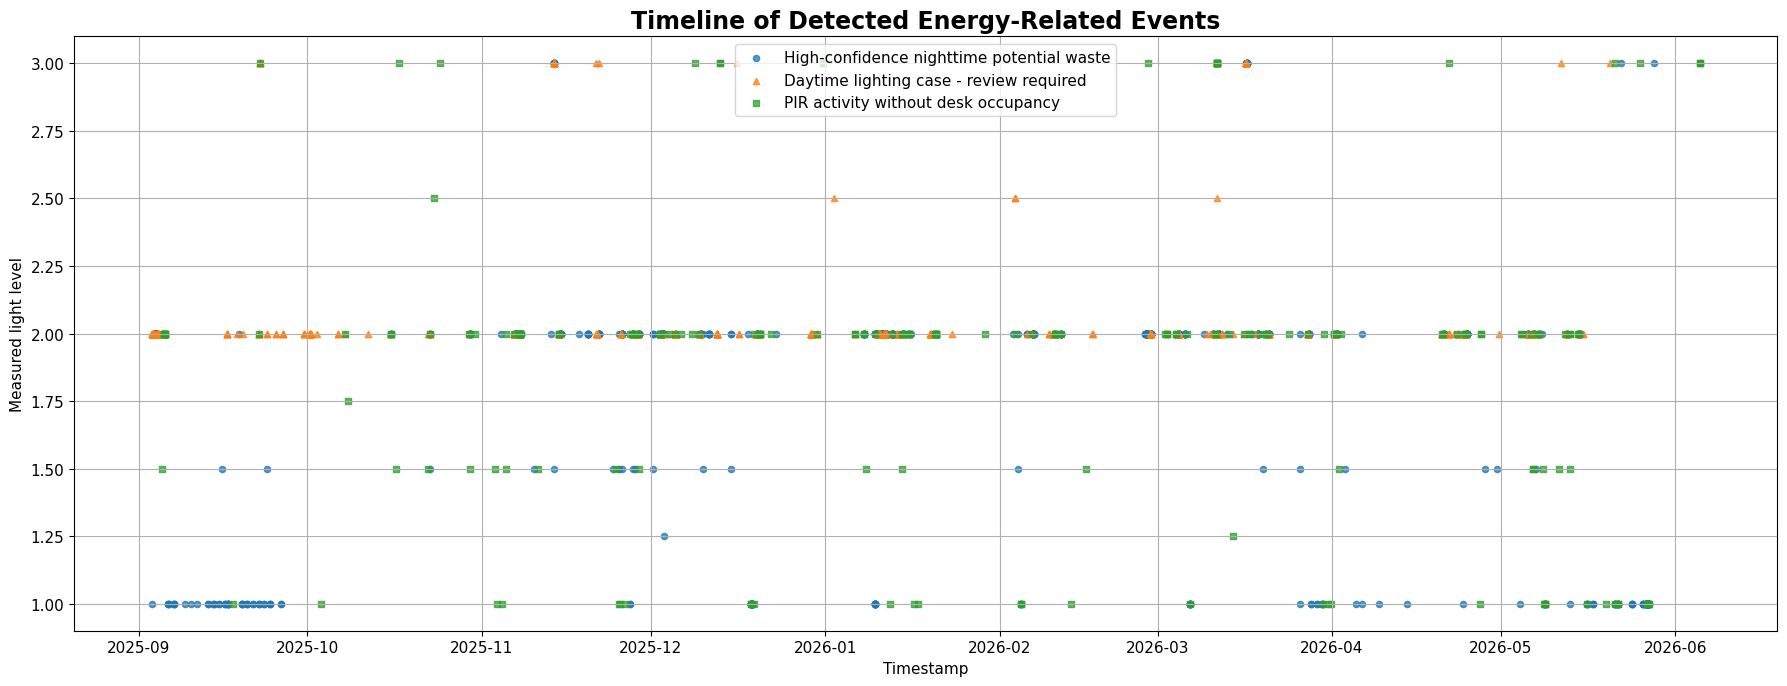

In [9]:
# TIMELINE OF DETECTED ENERGY-RELATED EVENTS

relevant_events = (
    df[
        df["energy_event"] != "No potential waste"
    ]
    .copy()
)

markers = {
    "High-confidence nighttime potential waste": "o",
    "Daytime lighting case - review required": "^",
    "PIR activity without desk occupancy": "s"
}

plt.figure(figsize=(18,7))

for event in relevant_events["energy_event"].unique():

    subset = relevant_events[
        relevant_events["energy_event"] == event
    ]

    plt.scatter(
        subset["ts"],
        subset["light_level_avg"],
        s=20,
        alpha=0.75,
        marker=markers.get(event, "o"),
        label=event
    )

plt.title(
    "Timeline of Detected Energy-Related Events",
    fontsize=17,
    weight="bold"
)

plt.xlabel("Timestamp")
plt.ylabel("Measured light level")

plt.legend()

plt.tight_layout()

plt.savefig(
    "Figure_Energy_3_Event_Timeline.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

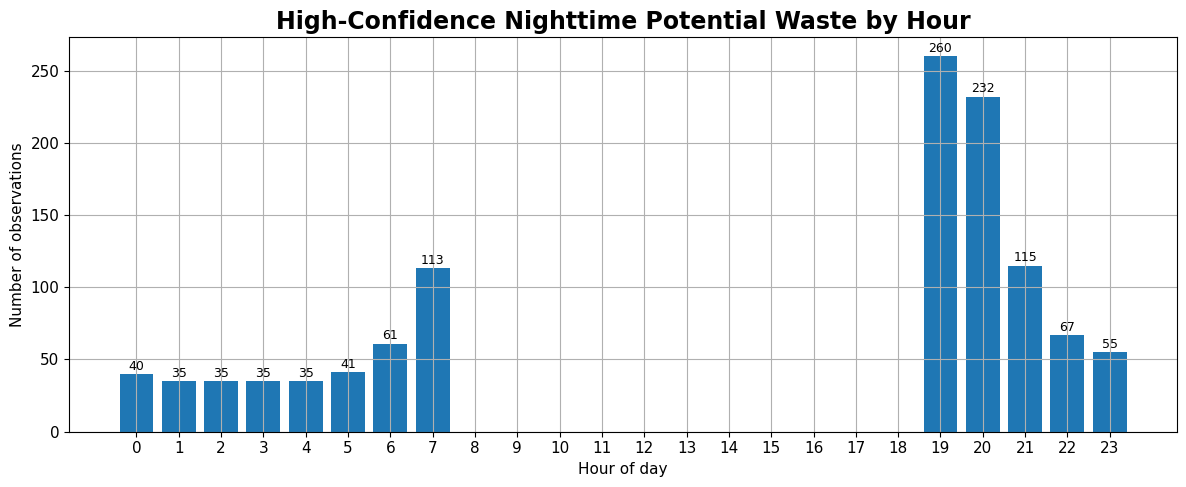

In [10]:
# HIGH-CONFIDENCE POTENTIAL WASTE BY HOUR

hourly_waste = (
    df[df["potential_energy_waste"] == 1]
    .groupby("hour")
    .size()
    .reindex(range(24), fill_value=0)
)

plt.figure(figsize=(12,5))

bars = plt.bar(
    hourly_waste.index,
    hourly_waste.values
)

plt.title(
    "High-Confidence Nighttime Potential Waste by Hour",
    fontsize=17,
    weight="bold"
)

plt.xlabel("Hour of day")
plt.ylabel("Number of observations")

plt.xticks(range(24))

# Display values above non-zero bars
for bar in bars:

    height = bar.get_height()

    if height > 0:

        plt.text(
            bar.get_x() + bar.get_width()/2,
            height + 3,
            f"{int(height)}",
            ha="center",
            fontsize=9
        )

plt.tight_layout()

plt.savefig(
    "Figure_Energy_4_High_Confidence_Waste_By_Hour.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 6. Estimated Duration of High-Confidence Cases

Because the dataset is recorded at 10-minute intervals, the cumulative duration of high-confidence potential-waste observations is estimated by multiplying the number of detected observations by the sampling interval.

This value represents the cumulative duration of flagged operating conditions and should not be interpreted as a direct measurement of energy consumption.

In [11]:
# ESTIMATED DURATION OF HIGH-CONFIDENCE POTENTIAL WASTE

sampling_interval_minutes = 10

high_confidence_observations = int(
    df["potential_energy_waste"].sum()
)

estimated_duration_minutes = (
    high_confidence_observations
    * sampling_interval_minutes
)

estimated_duration_hours = (
    estimated_duration_minutes / 60
)

duration_summary = pd.DataFrame({
    "Metric": [
        "High-confidence potential-waste observations",
        "Sampling interval (minutes)",
        "Estimated duration (minutes)",
        "Estimated duration (hours)"
    ],
    "Value": [
        high_confidence_observations,
        sampling_interval_minutes,
        estimated_duration_minutes,
        round(
            estimated_duration_hours,
            2
        )
    ]
})

display(duration_summary)

duration_summary.to_csv(
    "energy_waste_duration_summary.csv",
    index=False
)

print(
    "Saved: energy_waste_duration_summary.csv"
)

,Metric,Value
0,High-confidence potential-waste observations,1124.00
1,Sampling interval (minutes),10.00
2,Estimated duration (minutes),11240.00
3,Estimated duration (hours),187.33


Saved: energy_waste_duration_summary.csv


In [12]:
# EXPORT FINAL RESULTS

final_columns = [
    "ts",
    "occupied_desks",
    "pir_any",
    "confirmed_empty",
    "light_level_avg",
    "is_daytime",
    "is_nighttime",
    "energy_event",
    "potential_energy_waste"
]

df[final_columns].to_csv(
    "room_4_9_energy_waste_detection.csv",
    index=False
)

print(
    "Final energy-waste detection results saved successfully."
)

print(
    "File: room_4_9_energy_waste_detection.csv"
)

Final energy-waste detection results saved successfully.
File: room_4_9_energy_waste_detection.csv


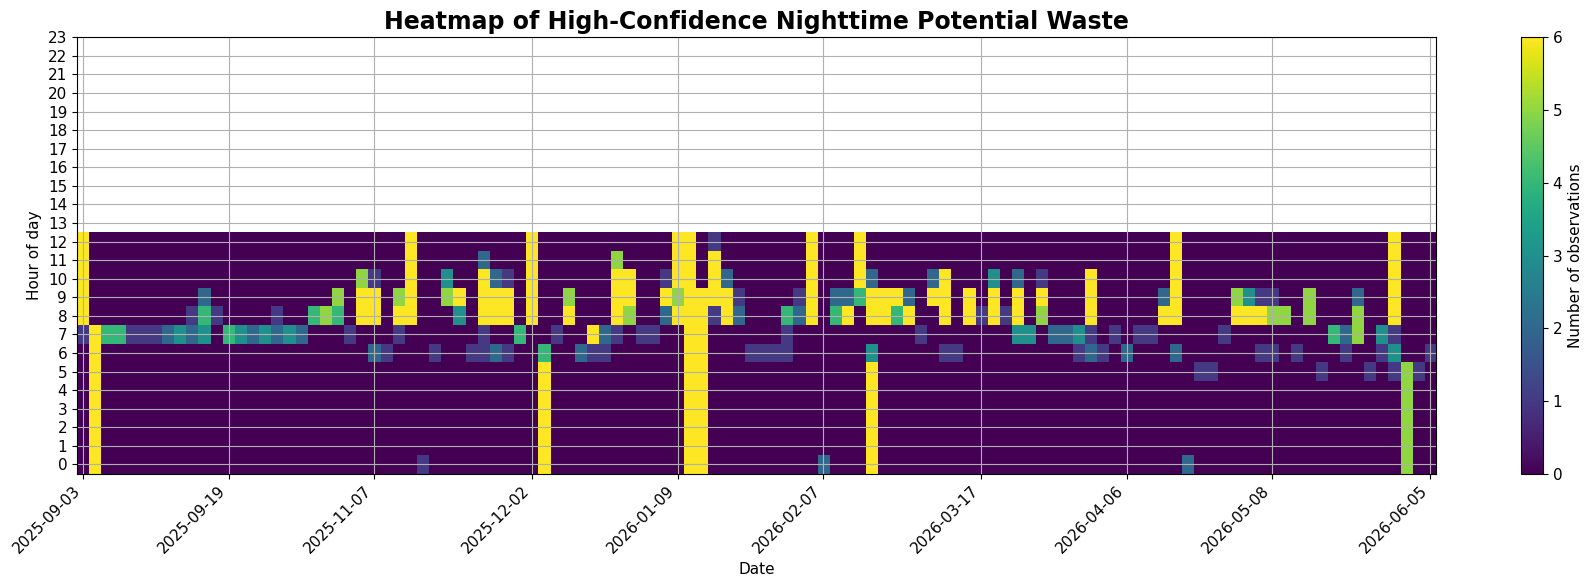

In [13]:
# HEATMAP OF HIGH-CONFIDENCE POTENTIAL WASTE

heatmap_source = (
    df[
        df["potential_energy_waste"] == 1
    ]
    .copy()
)

heatmap_source["date"] = (
    heatmap_source["ts"].dt.date
)

heatmap_source["hour"] = (
    heatmap_source["ts"].dt.hour
)

heatmap_pivot = heatmap_source.pivot_table(
    index="hour",
    columns="date",
    values="potential_energy_waste",
    aggfunc="sum",
    fill_value=0
)

plt.figure(figsize=(18,6))

im = plt.imshow(
    heatmap_pivot,
    aspect="auto",
    origin="lower",
    interpolation="nearest"
)

cbar = plt.colorbar(im)

cbar.set_label(
    "Number of observations"
)

plt.yticks(
    range(24),
    range(24)
)

# Avoid overcrowding the x-axis
tick_positions = np.linspace(
    0,
    len(heatmap_pivot.columns) - 1,
    10,
    dtype=int
)

plt.xticks(
    tick_positions,
    [
        str(heatmap_pivot.columns[i])
        for i in tick_positions
    ],
    rotation=45,
    ha="right"
)

plt.xlabel("Date")

plt.ylabel("Hour of day")

plt.title(
    "Heatmap of High-Confidence Nighttime Potential Waste",
    fontsize=17,
    weight="bold"
)

plt.tight_layout()

plt.savefig(
    "Figure_Energy_5_High_Confidence_Waste_Heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

##7. Scenario 4 Summary

Potential lighting-related energy waste was detected by combining Desk
Occupancy Sensors, PIR activity, measured light level and time-of-day
information.

A room was considered confidently empty only when no occupied desks and no
PIR activity were observed simultaneously. Lighting detected during
night-time empty periods was classified as high-confidence potential energy
waste.

Daytime lighting observations were treated more cautiously because the
available light-level measurements may include natural daylight. Therefore,
high daytime lighting in an empty room was classified as an anomaly requiring
further review rather than confirmed energy waste.

This approach reduces false detections and demonstrates how heterogeneous
sensor measurements can support energy-management decisions in a Smart Campus
environment.